In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Using the gradient in the loop.

In [3]:
def get_reach_boxes(file_path: str, variables: list[str], search: str) -> list[dict[str, list[float]]]:
    variable_bounds = []
    with open(file_path, 'r') as file:
        lines = file.readlines()
    i = 0
    while i < len(lines):
        line = lines[i].strip()
        if line.startswith("Dealing with the jump from " + search):
            bounds_dict = {}
            i += 1
            while i < len(lines) and not lines[i].strip().startswith("Done."):
                line = lines[i].strip()
                for var in variables:
                    if f"{var} bounds after reset:" in line:
                        start = line.find('[')
                        end = line.find(']')
                        if start != -1 and end != -1:
                            bounds_str = line[start+1:end]
                            lower, upper = map(float, bounds_str.split(','))
                            bounds_dict[var] = [lower, upper]
                i += 1
            if bounds_dict:
                variable_bounds.append(bounds_dict)
        else:
            i += 1
    return variable_bounds

In [4]:
import matplotlib.patches as patches
def create_reach_plots(reach_boxes=None, xlims=[-1,1], ylims=[-1,1], figsize=(9,6)):
    fig, ax1 = plt.subplots(layout='constrained', figsize=figsize)
    x_min, x_max = xlims
    ax1.set_xlim(x_min, x_max)
    ax1.set_ylim(ylims)


    if reach_boxes is not None:
        for setting in reach_boxes:
            for i, box in enumerate(get_reach_boxes(setting['filename'], setting['vars'], setting['search'])):
                x1, x2 = box[setting['vars'][0]]
                y1, y2 = box[setting['vars'][1]]
                # Skip if any values are nan or very large
                if np.isnan(x1) or np.isnan(x2) or np.isnan(y1) or np.isnan(y2):
                    continue
                if np.abs(x1) > 1e6 or np.abs(x2) > 1e6 or np.abs(y1) > 1e6 or np.abs(y2) > 1e6:
                    continue

                rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                        linewidth=2, edgecolor=setting['color'],
                                        facecolor='none', zorder=5, label=setting['label'] if i == 0 else "")
                ax1.add_patch(rect)
                
        ax1.legend()
    return fig

In [6]:
import numpy as np
import gymnasium as gym
from keras import models

MAX_EP_STEPS = 2000
num_trials = 20

model = models.load_model('sig16x16.h5')
env = gym.make("MountainCarContinuous-v0", render_mode=None) 
obs_list = []
for i in range(num_trials):

    observation = env.reset(options={"low": -0.54, "high":  -0.48})[0]
    obs = [observation]
    rew = 0
    u = model.predict(observation.reshape(1,len(observation)))[0]
    print(f"{u=}")

    for e in range(MAX_EP_STEPS):

        observation, reward, terminated, truncated, _ = env.step(u)
        obs.append(observation)                    
        u = model.predict(observation.reshape(1,len(observation)))[0]
        
        rew += reward
        if terminated or truncated:
            break
    obs_list.append(np.array(obs))
env.close()

I0000 00:00:1788278018.332622 1262329 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788278018.333462 1262329 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788278018.386417 1262329 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788278021.550696 1262329 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
u=array([-0.66317767], dtype=float32)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━

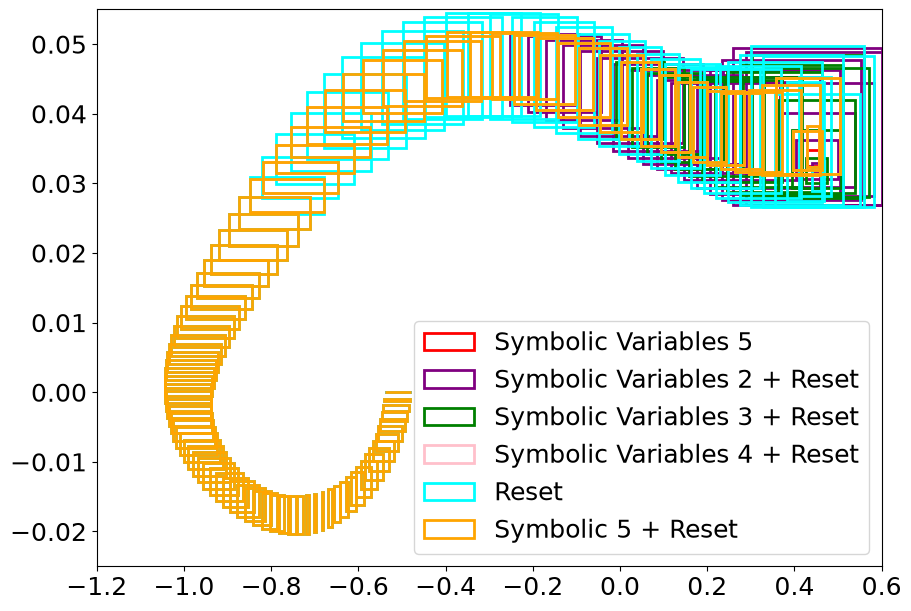

In [5]:
plt.rcParams.update({'font.size': 18})
f = create_reach_plots(reach_boxes=[
                    {
                       "filename": "../../outputs/out_sym_5.txt",
                       "color": "red",
                       "vars" : ["x1","x2"],
                       "label": "Symbolic Variables 5",
                       "search" : "DNN to _symbolic"
                   },
                   {
                       "filename": "../../outputs/out_sym_2_reset.txt",
                       "color": "purple",
                       "vars" : ["x1","x2"],
                       "label": "Symbolic Variables 2 + Reset",
                       "search" : "DNN to _symbolic"
                   },
                   {
                       "filename": "../../outputs/out_sym_3_reset.txt",
                       "color": "green",
                       "vars" : ["x1","x2"],
                       "label": "Symbolic Variables 3 + Reset",
                       "search" : "DNN to _symbolic"
                   },
                   {
                       "filename": "../../outputs/out_sym_4_reset.txt",
                       "color": "pink",
                       "vars" : ["x1","x2"],
                       "label": "Symbolic Variables 4 + Reset",
                       "search" : "DNN to _symbolic"
                   },
                   {
                       "filename": "../../outputs/out_reset.xml",
                       "color": "cyan",
                       "vars" : ["x1","x2"],
                       "label": "Reset",
                       "search" : "DNN to _reset"
                   },
                   {
                       "filename": "../../outputs/out_sym_5_with_reset.txt",
                       "color": "orange",
                       "vars" : ["x1","x2"],
                       "label": "Symbolic 5 + Reset",
                       "search" : "DNN to _symbolic"
                   }
                   ], xlims=[-1.2,0.6], ylims=[-0.025, 0.055])
                #    ], xlims=[-0.6,-0.4], ylims=[-0.01, 0.01])
                #    ], xlims=[0.2,0.6], ylims=[0.03, 0.05])


In [7]:
for i in range(len(obs_list)):
    f.get_axes()[0].plot(obs_list[i][:,0], obs_list[i][:,1], color = "blue", label="Trajectory" if i == 0 else "")
f.get_axes()[0].legend()


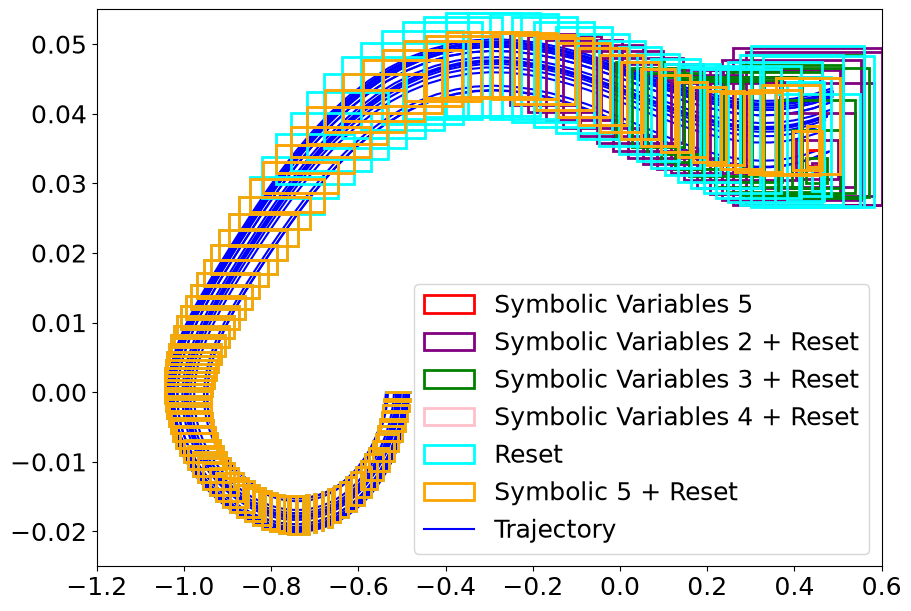

In [8]:
f

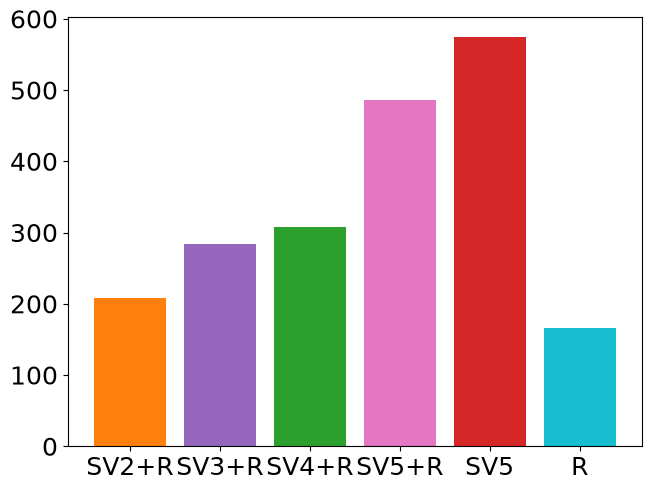

In [15]:
times = [60+ 147.72, 60 + 223.62, 60 + 248.16, 60 + 425.47, 60 + 514.52, 60 + 105.67]

fig, ax = plt.subplots(layout='constrained')

colors = [
    "tab:orange",
    "tab:purple",
    "tab:green",
    "tab:pink",
    "tab:red",
    "tab:cyan",
]

labels = [
    "SV2+R",
    "SV3+R",
    "SV4+R",
    "SV5+R",
    "SV5",
    "R",
]
times = [60+ 147.72, 60 + 223.62, 60 + 248.16, 60 + 425.47, 60 + 514.52, 60 + 105.67]
bar_colors = ['tab:red', 'tab:blue', 'tab:red', 'tab:orange']

ax.bar(labels, times, color=colors)

plt.show()
